In [39]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
model_filename = "best_random_forest_model.pkl"
model = joblib.load(model_filename)

data = pd.read_csv("selected_genes_500_xg.csv")
target = data["Symbol"].map({"sl": 0, "hgdn": 1, "lgdn": 2, "ehcc": 3, "phcc": 4})
data_predictors = data.drop(columns=["Symbol"])

top_features = ["DNAJB14", "CTBS", "ZBTB43", "FGF23", "COLEC10"]  # Replace with the top features
x_data = data_predictors[top_features]

explainer = shap.Explainer(model, x_data)

shap_values = explainer(x_data)

 98%|===================| 3773/3850 [00:19<00:00]        

In [8]:
print(f"x_data type: {type(x_data)}")
print(f"shap_values type: {type(shap_values)}")
print(f"x_data columns: {x_data.columns}")

x_data type: <class 'pandas.core.frame.DataFrame'>
shap_values type: <class 'shap._explanation.Explanation'>
x_data columns: Index(['DNAJB14', 'CTBS', 'ZBTB43', 'FGF23', 'COLEC10'], dtype='object')


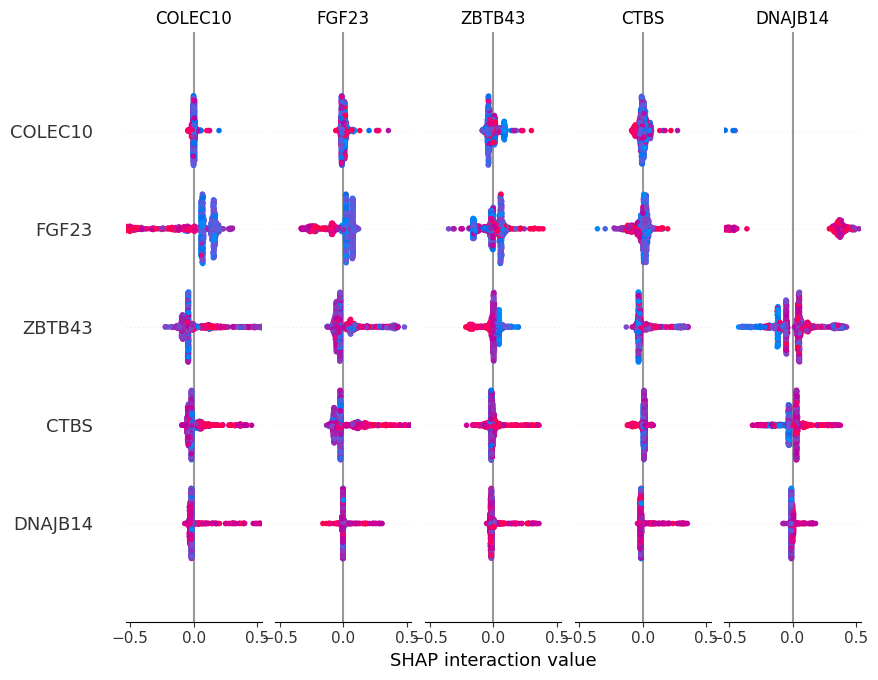

In [50]:
shap.summary_plot(shap_values.values, x_data, feature_names=x_data.columns, plot_type="bar")